In [1]:
# ============================================================
# TASK 2 : Feature Engineering, Model Optimization
#          & Performance Comparison
# Dataset : California Housing Dataset
# Models  : Linear Regression, Ridge Regression, Decision Tree
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# ============================================================
# LOAD THE CALIFORNIA HOUSING DATASET
# ============================================================

data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename('HousePrice')], axis=1)

print("✅ Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

✅ Dataset loaded successfully!
Shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# ============================================================
# SEPARATE FEATURES AND TARGET VARIABLE
# ============================================================

X = df.drop(columns='HousePrice')
y = df['HousePrice']

print("✅ Features and target separated!")
print(f"\nFeatures (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")
print(f"\nFeatures used: {list(X.columns)}")

✅ Features and target separated!

Features (X) shape : (20640, 8)
Target   (y) shape : (20640,)

Features used: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [4]:
# ============================================================
# FEATURE SCALING USING STANDARDSCALER
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to dataframe for better readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("✅ Feature scaling applied successfully!")
print("\nBefore Scaling (original values):")
print(X.describe().round(2))
print("\nAfter Scaling (standardized values):")
print(X_scaled_df.describe().round(2))

✅ Feature scaling applied successfully!

Before Scaling (original values):
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  
count  20640.00   20640.00  
mean      35.63    -119.57  
std        2.14       2.00  
min       32.54    -124.35  
25%       33.93    -121.80  
50%       34.26    -118.49  
75%       37.71    -118.01  
max       41.95    -114.31  

After Scaling 

In [5]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("✅ Data split successfully!")
print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

✅ Data split successfully!

Training samples : 16512
Testing samples  : 4128


In [6]:
# ============================================================
# TRAIN MULTIPLE MODELS
# ============================================================

models = {
    "Linear Regression" : LinearRegression(),
    "Ridge Regression"  : Ridge(alpha=1.0),
    "Decision Tree"     : DecisionTreeRegressor(max_depth=5)
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    results[name] = {
        "MAE"  : round(mae, 4),
        "RMSE" : round(rmse, 4),
        "R²"   : round(r2, 4)
    }
    
    print(f"✅ {name} trained!")

print("\n All 3 models trained successfully!")

✅ Linear Regression trained!
✅ Ridge Regression trained!
✅ Decision Tree trained!

 All 3 models trained successfully!


In [7]:
# ============================================================
# MODEL PERFORMANCE COMPARISON
# ============================================================

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R²', ascending=False)

print("=" * 55)
print("        MODEL PERFORMANCE COMPARISON TABLE")
print("=" * 55)
print(results_df.to_string())
print("=" * 55)

# Identify best model
best_model_name = results_df['R²'].idxmax()
best_r2 = results_df['R²'].max()
best_rmse = results_df.loc[best_model_name, 'RMSE']

print(f"\n🏆 Best Model : {best_model_name}")
print(f"   R²         : {best_r2}")
print(f"   RMSE       : {best_rmse}")

        MODEL PERFORMANCE COMPARISON TABLE
                      MAE    RMSE      R²
Decision Tree      0.5223  0.7242  0.5997
Linear Regression  0.5332  0.7456  0.5758
Ridge Regression   0.5332  0.7456  0.5758

🏆 Best Model : Decision Tree
   R²         : 0.5997
   RMSE       : 0.7242


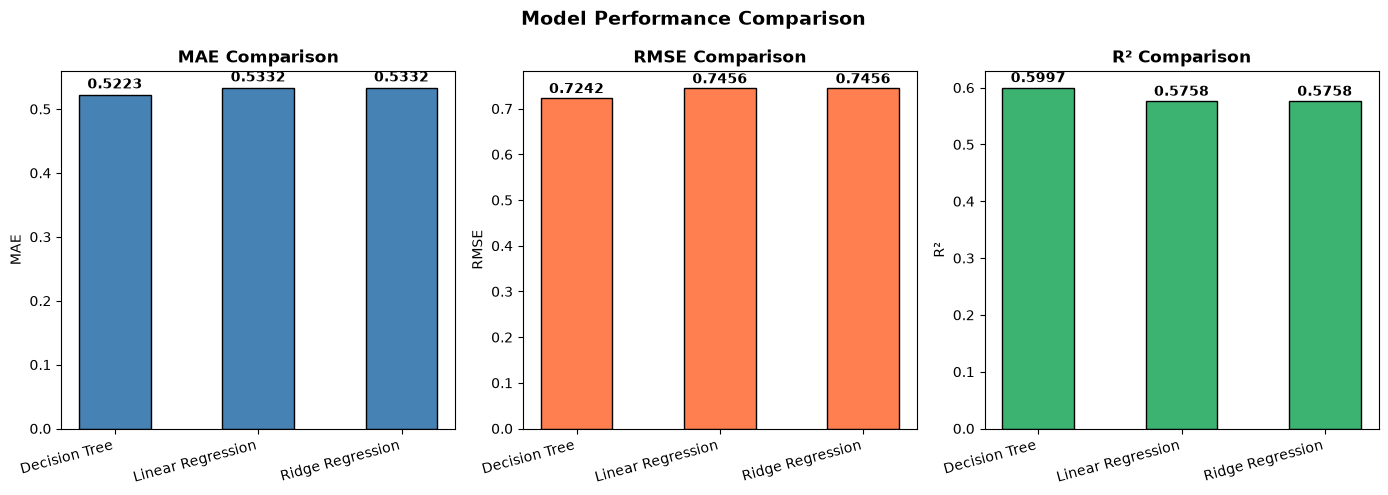

✅ Comparison chart saved!


In [9]:
# ============================================================
# MODEL COMPARISON BAR CHART
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['MAE', 'RMSE', 'R²']
colors  = ['steelblue', 'coral', 'mediumseagreen']

for i, metric in enumerate(metrics):
    axes[i].bar(results_df.index, results_df[metric], 
                color=colors[i], edgecolor='black', width=0.5)
    axes[i].set_title(f'{metric} Comparison', fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_xticklabels(results_df.index, rotation=15, ha='right')
    
    for j, val in enumerate(results_df[metric]):
        axes[i].text(j, val + 0.01, str(val), ha='center', fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Comparison chart saved!")

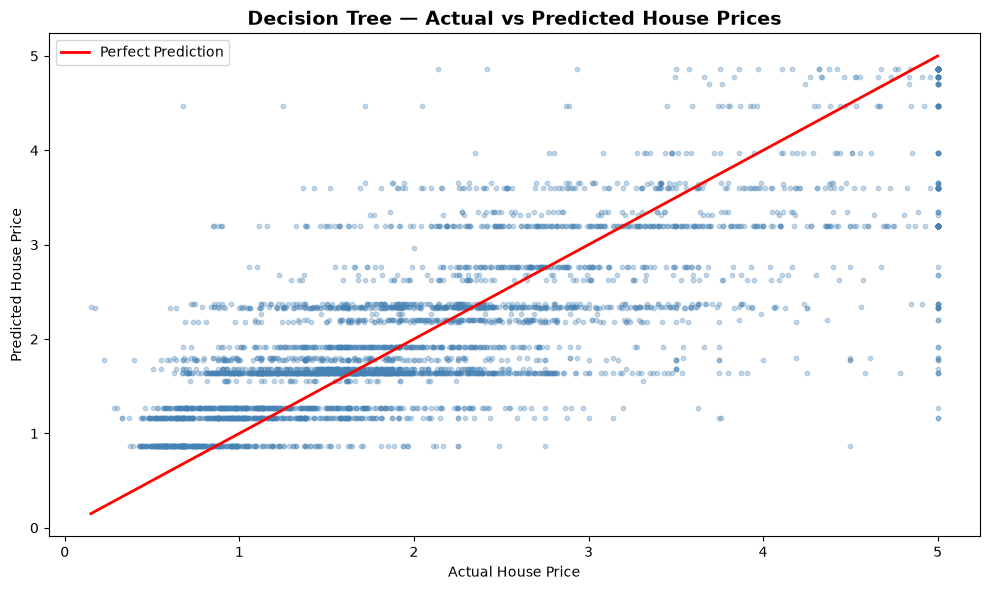

✅ Plot saved!


In [10]:
# ============================================================
# ACTUAL VS PREDICTED PLOT - BEST MODEL (DECISION TREE)
# ============================================================

best_model = DecisionTreeRegressor(max_depth=5)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Decision Tree — Actual vs Predicted House Prices', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('best_model_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Plot saved!")

In [11]:
# ============================================================
# SAVE THE BEST MODEL USING JOBLIB
# ============================================================

import joblib

joblib.dump(best_model, 'best_model_decision_tree.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Best model saved as 'best_model_decision_tree.pkl'")
print("✅ Scaler saved as 'scaler.pkl'")

✅ Best model saved as 'best_model_decision_tree.pkl'
✅ Scaler saved as 'scaler.pkl'


In [12]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=" * 55)
print("       TASK 2 — FINAL SUMMARY")
print("=" * 55)
print(f"\n📦 Dataset      : California Housing")
print(f"📊 Total Rows   : {df.shape[0]}")
print(f"🔢 Features     : {X.shape[1]}")
print(f"⚙️  Scaling      : StandardScaler applied")
print(f"🏋️  Train Size   : {X_train.shape[0]}")
print(f"🧪 Test Size    : {X_test.shape[0]}")
print("\n--- All Models Performance ---")
print(results_df.to_string())
print(f"\n🏆 Best Model   : {best_model_name}")
print(f"   R²           : {best_r2}")
print(f"   RMSE         : {best_rmse}")
print("\n--- Why Decision Tree Won ---")
print("  • Captures non-linear relationships")
print("  • Feature scaling improved all models")
print("  • Ridge = Linear here (no overfitting)")
print("=" * 55)
print("\n✅ Task 2 Complete!")

       TASK 2 — FINAL SUMMARY

📦 Dataset      : California Housing
📊 Total Rows   : 20640
🔢 Features     : 8
⚙️  Scaling      : StandardScaler applied
🏋️  Train Size   : 16512
🧪 Test Size    : 4128

--- All Models Performance ---
                      MAE    RMSE      R²
Decision Tree      0.5223  0.7242  0.5997
Linear Regression  0.5332  0.7456  0.5758
Ridge Regression   0.5332  0.7456  0.5758

🏆 Best Model   : Decision Tree
   R²           : 0.5997
   RMSE         : 0.7242

--- Why Decision Tree Won ---
  • Captures non-linear relationships
  • Feature scaling improved all models
  • Ridge = Linear here (no overfitting)

✅ Task 2 Complete!
